# Q3 — MLM Pretraining then Classification Fine-tuning on 20 Newsgroups

**HSLU NALAPRO project — Question 3.** _Author: Dan Waititu (`danwwaititu@gmail.com`)._

## Research question

> _"Fine-tune a BERT model by masking some words out instead of fine tuning the classification task. After that, now finetune the model on the classification task. Evaluate and discuss the results."_ — `project_description/NALAPRO Project.pdf`, §2 Question 3.

In modern terminology this is **domain-adaptive pretraining** (Gururangan et al., 2020, _Don't Stop Pretraining_). We run a two-stage pipeline:

| Stage | Objective | Inputs | Output |
|---|---|---|---|
| **A — MLM pretraining** | Masked language modelling | 20NG train texts (labels ignored) | Adapted encoder checkpoint |
| **B — Classification fine-tune** | 20-way cross-entropy | 20NG train/val/test with labels | Classifier + test metrics |

The Stage-B hyperparameters are **identical** to the Q2 baseline (`models/q2_results/q2b_baseline.json`), so the only variable changing between Q2 and Q3 is the encoder's starting weights. Any delta in test metrics is attributable to the MLM stage.

## Deliverables produced by this notebook

- `models/q3_results/mlm_ckpt/` — Stage-A MLM checkpoint (HF format).
- `models/q3_results/q3_pretrain_log.json` — per-epoch MLM train/eval loss + perplexity.
- `models/q3_results/q3_finetune_results.json` — Stage-B test metrics + W&B run names.
- `figures/q3_mlm_loss.png` — MLM loss & perplexity curve.
- `figures/q3_confusion_matrix.png` — Stage-B confusion matrix on the 20NG test set.
- `figures/q3_vs_q2_bars.png` — side-by-side accuracy / macro-F1 / per-class F1 comparison vs Q2b.

## W&B runs

Project: `hslu-nalapro` · group: `q3` · two runs — `q3-mlm-pretrain` (Stage A) and `q3-mlm-then-finetune` (Stage B). Paste the run URLs into the placeholder below once executed.

- Stage A: <https://wandb.ai/danwwaititu-hochschule-luzern/hslu-nalapro?nw=nwuserdanwwaititu> _(group `q3`)_
- Stage B: same group.

## AI tool disclosure

Per spec §7, this notebook (cells + markdown) was co-authored with **Claude Code** (Anthropic, model `claude-opus-4-7`). All design decisions, the MLM corpus choice, the hyperparameter freeze, and the discussion section reflect the author's judgement. The model weights and metrics are reproduced from a single local execution on Apple M-series (MPS); the seed is `nlp_project.SEED = 42` throughout.

## 1. Setup

**What:** import everything, seed all RNGs, declare output directories.

**Why centralise seeding:** the project's `set_seed` (in `src/nlp_project/__init__.py`) seeds Python `random`, NumPy, `PYTHONHASHSEED`, and PyTorch from `SEED = 42`. HuggingFace's `Trainer` additionally receives `seed=SEED` and `data_seed=SEED` through `make_mlm_training_args` / `make_training_args`, so Stage A and Stage B both fire from the same RNG state.

**Why `autoreload`:** the notebook is a thin orchestrator; if I edit the package modules in another editor, autoreload picks the changes up without restarting the kernel.

In [1]:
%load_ext autoreload
%autoreload 2

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import wandb
from transformers import AutoModelForSequenceClassification, AutoTokenizer

from nlp_project import SEED, set_seed
from nlp_project.bert_data import build_splits
from nlp_project.bert_train import run_finetune
from nlp_project.data import load_20ng
from nlp_project.eval import plot_confusion
from nlp_project.mlm_pretrain import run_mlm_pretrain

set_seed()

DEVICE = (
    'mps' if torch.backends.mps.is_available()
    else 'cuda' if torch.cuda.is_available()
    else 'cpu'
)
print(f'device = {DEVICE}; seed = {SEED}')

RESULTS_DIR = Path('../models/q3_results'); RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MLM_CKPT_DIR = RESULTS_DIR / 'mlm_ckpt'
FT_OUT_DIR = RESULTS_DIR / 'finetune'
FIG_DIR = Path('../figures'); FIG_DIR.mkdir(exist_ok=True)
Q2_RESULTS = Path('../models/q2_results/q2b_baseline.json')


device = mps; seed = 42


## 2. Data

### 2.1 Load 20 Newsgroups

**What:** fetch the 20NG train/test splits via `nlp_project.data.load_20ng(remove=True)`.

**Why `remove=True`:** the spec (§3 *label leakage*) explicitly notes that the message headers, footers, and quoted text contain the newsgroup name and similar tells that trivialise the task. We strip them. Q1 and Q2 use exactly the same setting — keeping it consistent makes the Q1↔Q2↔Q3 comparison meaningful.

### 2.2 Which corpus is used in MLM?

We pretrain on the **train split only** — no test, no labels. The decision was discussed with the user and recorded in the plan file `docs/superpowers/plans/2026-05-18-q3-mlm-pretrain.md`:

> *Why train-split-only for MLM*: keeps the Q2 ↔ Q3 comparison clean — Q2's encoder also never saw the test text during training. Domain-adaptive pretraining literature supports either choice, but for our small corpus the cleaner experimental contrast outweighs the small extra unlabeled data.


In [2]:
train_docs, train_labels, test_docs, test_labels, label_names = load_20ng(remove=True)
print(f'train docs : {len(train_docs):>6d}')
print(f'test docs  : {len(test_docs):>6d}')
print(f'n_classes  : {len(label_names):>6d}')
print()
print('Example doc (first 500 chars):')
print('-' * 60)
print(train_docs[0][:500])
print('-' * 60)
print(f'label = {label_names[train_labels[0]]!r}')


train docs :  11314
test docs  :   7532
n_classes  :     20

Example doc (first 500 chars):
------------------------------------------------------------
I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.
------------------------------------------------------------
label = 'rec.autos'


In [3]:
# Per-class document counts (sanity check — 20NG is approximately balanced).
counts = pd.Series(train_labels).value_counts().sort_index()
counts.index = label_names
counts.rename('n_train_docs').to_frame()


,n_train_docs
alt.atheism,480
comp.graphics,584
comp.os.ms-windows.misc,591
comp.sys.ibm.pc.hardware,590
comp.sys.mac.hardware,578
comp.windows.x,593
misc.forsale,585
rec.autos,594
rec.motorcycles,598
rec.sport.baseball,597


## 3. Stage A — MLM pretraining

### 3.1 What MLM is doing here

We continue BERT's original pretraining objective on the 20NG train corpus. For each input sequence, HuggingFace's `DataCollatorForLanguageModeling` does the canonical Devlin-et-al.
masking on the fly:

- Select **15%** of the WordPiece tokens uniformly at random.
- Of those, replace 80% with `[MASK]`, 10% with a random vocabulary token, and 10% leave unchanged.
- The labels tensor is `-100` everywhere except the selected positions, where it carries the original token id. PyTorch's cross-entropy ignores the `-100` positions.

**Why `mlm_probability=0.15`:** BERT's original default. We are not tuning the mask rate — the research question is *does the extra stage help at all*, not *what is the optimal mask rate*.

### 3.2 Why we report `eval_loss` and perplexity (not accuracy / F1)

MLM has no classification labels, so accuracy and macro-F1 do not apply. The two standard metrics are cross-entropy loss on held-out masked tokens and its exponentiation, **perplexity** (`PPL = exp(eval_loss)`). Lower is better for both. We use `eval_loss` as the `metric_for_best_model` so the Trainer's `load_best_model_at_end=True` restores the lowest-loss epoch before saving.

### 3.3 Why a separate MLM eval split

Inside `run_mlm_pretrain` we carve a fresh 90/10 split out of the train docs for MLM train/eval. This split is *independent* of the classification val set carved by `train_val_split` in Stage B — if we reused the classification val for MLM, Stage A would indirectly leak information into Stage B's early-stopping signal. The two stages use disjoint validation pools.

In [4]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

# Stage A hyperparameters — chosen to match Q2's training budget per epoch.
MLM_CONFIG = {
    'model': 'bert-base-uncased',
    'lr': 5e-5,
    'epochs': 3,
    'batch_size': 16,
    'max_length': 256,
    'mlm_probability': 0.15,
    'mlm_val_frac': 0.1,
    'weight_decay': 0.01,
    'warmup_ratio': 0.1,
    'seed': SEED,
}
MLM_CONFIG


{'model': 'bert-base-uncased',
 'lr': 5e-05,
 'epochs': 3,
 'batch_size': 16,
 'max_length': 256,
 'mlm_probability': 0.15,
 'mlm_val_frac': 0.1,
 'weight_decay': 0.01,
 'warmup_ratio': 0.1,
 'seed': 42}

### 3.4 Run Stage A

On Apple Silicon (M-series, MPS) this takes roughly 30–60 minutes for ~11k docs × 256 tokens × 3 epochs. The Trainer logs train loss every `logging_steps=50` updates and `eval_loss` once per epoch; W&B picks both up automatically through `report_to=['wandb']`.

We `wandb.init` before the call and `wandb.finish` after, mirroring the pattern used in Q2 — `run_mlm_pretrain` itself is pure with respect to the W&B session.

In [5]:
wandb.init(
    project='hslu-nalapro',
    group='q3',
    name='q3-mlm-pretrain',
    config=MLM_CONFIG,
    reinit=True,
)

stage_a = run_mlm_pretrain(
    tokenizer=tokenizer,
    train_docs=train_docs,
    out_dir=MLM_CKPT_DIR,
    model_name=MLM_CONFIG['model'],
    lr=MLM_CONFIG['lr'],
    epochs=MLM_CONFIG['epochs'],
    batch_size=MLM_CONFIG['batch_size'],
    max_length=MLM_CONFIG['max_length'],
    mlm_probability=MLM_CONFIG['mlm_probability'],
    mlm_val_frac=MLM_CONFIG['mlm_val_frac'],
    weight_decay=MLM_CONFIG['weight_decay'],
    warmup_ratio=MLM_CONFIG['warmup_ratio'],
    run_name='q3-mlm-pretrain',
    report_to=['wandb'],
)
wandb.finish()

print(f'best eval_loss = {stage_a["best_eval_loss"]:.4f}')
print(f'perplexity     = {stage_a["perplexity"]:.4f}')


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: danwwaititu (danwwaititu-hochschule-luzern) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss
1,2.317809,2.215386
2,2.223445,2.095254
3,2.121313,2.042461


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

eval/loss,█▃▁
eval/runtime,▁█▃
eval/samples_per_second,█▁▆
eval/steps_per_second,█▁▆
train/epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇████
train/global_step,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇████
train/grad_norm,▆▄▂▆▅▅▄▃▄▅▇▄▂▄▇█▄▂▂▄▂▁▂▅▅▄▆▁▃▃▃▅▃▄▂▅▂▅
train/learning_rate,▃▅▆███▇▇▇▇▇▆▆▆▆▆▅▅▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁
train/loss,█▇▆▆▅▅▅▅▄▄▄▄▃▃▃▂▂▂▃▃▂▂▃▃▃▁▃▁▂▂▂▁▁▂▂▂▁▁
eval/loss,2.04246
eval/runtime,25.0462


best eval_loss = 2.0425
perplexity     = 7.7096


### 3.5 Serialize Stage-A logs and plot the loss curve

We persist the Trainer's `log_history` (a list of dicts, one per logged step or eval) to JSON so the comparison cell at the end can re-render the plot without re-running training. The figure is saved to `figures/q3_mlm_loss.png` for the report.

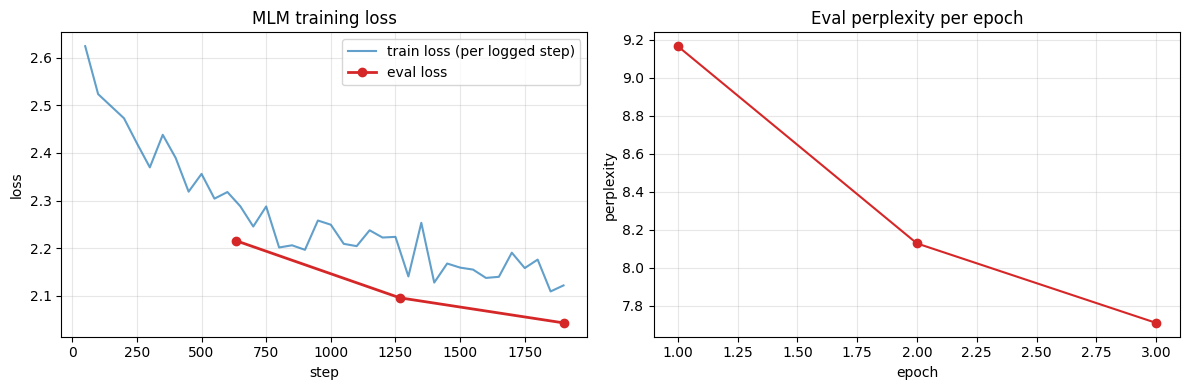

In [6]:
log = stage_a['log_history']
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / 'q3_pretrain_log.json').write_text(json.dumps({
    'config': MLM_CONFIG,
    'best_eval_loss': stage_a['best_eval_loss'],
    'perplexity': stage_a['perplexity'],
    'log_history': log,
}, indent=2, default=float))

train_steps = [e['step'] for e in log if 'loss' in e and 'eval_loss' not in e]
train_loss = [e['loss'] for e in log if 'loss' in e and 'eval_loss' not in e]
eval_epochs = [e['epoch'] for e in log if 'eval_loss' in e]
eval_loss = [e['eval_loss'] for e in log if 'eval_loss' in e]
eval_ppl = [math.exp(l) for l in eval_loss]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_steps, train_loss, label='train loss (per logged step)', color='tab:blue', alpha=0.7)
if eval_loss:
    # Map eval points onto the step axis by piecewise-linear interpolation.
    steps_per_epoch = train_steps[-1] / log[-1]['epoch'] if train_steps else 1.0
    eval_x = [e * steps_per_epoch for e in eval_epochs]
    ax1.plot(eval_x, eval_loss, label='eval loss', color='tab:red', marker='o', linewidth=2)
ax1.set_xlabel('step'); ax1.set_ylabel('loss'); ax1.set_title('MLM training loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(eval_epochs, eval_ppl, marker='o', color='tab:red')
ax2.set_xlabel('epoch'); ax2.set_ylabel('perplexity'); ax2.set_title('Eval perplexity per epoch')
ax2.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / 'q3_mlm_loss.png', dpi=150)
plt.show()


## 4. Stage B — Classification fine-tune from the MLM checkpoint

### 4.1 What changes vs Q2b, and what stays the same

Everything except the encoder's starting weights stays the same. The point of an experiment is to isolate the effect of one change at a time. Q2b's run config (read from `models/q2_results/q2b_baseline.json`) was:

| Setting | Q2b baseline | Q3 Stage B |
|---|---|---|
| Encoder init | `bert-base-uncased` (Hub) | `models/q3_results/mlm_ckpt/` (our MLM-pretrained) |
| max_length | 256 | **256** |
| Learning rate | 2e-5 | **2e-5** |
| Batch size | 16 | **16** |
| Epochs | 3 | **3** |
| Weight decay | 0.01 | **0.01** |
| Warmup ratio | 0.1 | **0.1** |
| Seed | 42 | **42** |
| Trainer | HF `Trainer` (MPS-safe flags) | **same** |

Because `build_splits` reuses `data.train_val_split(seed=42)`, the val indices are identical to Q1 and Q2 — `tests/test_bert_data.py::test_build_splits_matches_q1_val_indices` enforces this.

### 4.2 Loading the MLM checkpoint into a classification head

`AutoModelForSequenceClassification.from_pretrained(<mlm_ckpt>, num_labels=20, ...)` reuses the encoder layers from the MLM checkpoint and *randomly initializes* a fresh classifier head on top (the MLM head is discarded). The classifier head's random init is seeded by `set_seed()`, so the head start is identical to a Q2b re-run.

In [7]:
splits = build_splits(tokenizer_name='bert-base-uncased', max_length=256)
print(f'train: {len(splits["train"])}, val: {len(splits["val"])}, test: {len(splits["test"])}')
print(f'n classes: {len(splits["label_names"])}')


train: 10182, val: 1132, test: 7532
n classes: 20


In [8]:
FT_CONFIG = {
    'init_from': 'q3-mlm-ckpt',
    'mlm_ckpt': str(MLM_CKPT_DIR),
    'max_length': 256,
    'lr': 2e-5,
    'epochs': 3,
    'batch_size': 16,
    'weight_decay': 0.01,
    'warmup_ratio': 0.1,
    'seed': SEED,
}

# Re-seed before head init so the classifier weights are deterministic.
set_seed()
model = AutoModelForSequenceClassification.from_pretrained(
    str(MLM_CKPT_DIR),
    num_labels=len(splits['label_names']),
    id2label={i: n for i, n in enumerate(splits['label_names'])},
    label2id={n: i for i, n in enumerate(splits['label_names'])},
)
type(model).__name__


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: ../models/q3_results/mlm_ckpt
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


'BertForSequenceClassification'

### 4.3 Run Stage B

We delegate to `bert_train.run_finetune` — the exact same function Q2 used. The model arg lets us pass our MLM-pretrained encoder instead of having `run_finetune` download fresh weights from the Hub. On MPS, Stage B takes roughly 15–30 minutes.

In [9]:
wandb.init(
    project='hslu-nalapro',
    group='q3',
    name='q3-mlm-then-finetune',
    config=FT_CONFIG,
    reinit=True,
)

stage_b = run_finetune(
    splits=splits,
    model=model,
    out_dir=FT_OUT_DIR,
    lr=FT_CONFIG['lr'],
    epochs=FT_CONFIG['epochs'],
    batch_size=FT_CONFIG['batch_size'],
    run_name='q3-mlm-then-finetune',
    weight_decay=FT_CONFIG['weight_decay'],
    warmup_ratio=FT_CONFIG['warmup_ratio'],
    report_to=['wandb'],
)
wandb.finish()

tm = stage_b['test_metrics']
print(f'accuracy   = {tm["accuracy"]:.4f}')
print(f'macro_f1   = {tm["macro_f1"]:.4f}')
print(f'best eval  = {stage_b["best_eval_metric"]:.4f}')


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.990939,0.920277,0.726148,0.703575
2,0.693708,0.807576,0.756184,0.738971
3,0.546013,0.801105,0.762367,0.748442


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

eval/accuracy,▁▇█
eval/loss,█▁▁
eval/macro_f1,▁▇█
eval/runtime,█▃▁
eval/samples_per_second,▁▆█
eval/steps_per_second,▁▆█
test/accuracy,▁
test/loss,▁
test/macro_f1,▁
test/runtime,▁
+7,...


accuracy   = 0.7160
macro_f1   = 0.6981
best eval  = 0.7484


### 4.4 Serialize Stage-B results and render the confusion matrix

We dump the same JSON shape as Q2b so the comparison cell can read both files with identical code. The CM PNG goes into `figures/` for the scientific report.

In [10]:
tm = stage_b['test_metrics']
(RESULTS_DIR / 'q3_finetune_results.json').write_text(json.dumps({
    'name': 'q3-mlm-then-finetune',
    'config': FT_CONFIG,
    'accuracy': float(tm['accuracy']),
    'macro_f1': float(tm['macro_f1']),
    'per_class_f1': [float(x) for x in tm['per_class_f1']],
    'confusion_matrix': tm['confusion_matrix'].tolist(),
    'best_eval_macro_f1': float(stage_b['best_eval_metric']),
}, indent=2))

plot_confusion(
    cm=tm['confusion_matrix'],
    label_names=splits['label_names'],
    save_path=FIG_DIR / 'q3_confusion_matrix.png',
    title='Q3 — MLM-pretrained then fine-tuned (test set)',
)
print('Saved figure to', FIG_DIR / 'q3_confusion_matrix.png')


Saved figure to ../figures/q3_confusion_matrix.png


## 5. Comparison — Q2 baseline vs Q3 (MLM-then-fine-tune)

**What:** load the Q2b baseline JSON and the Q3 Stage-B JSON we just wrote, and present head-to-head numbers + plots.

**Why:** the spec asks us to "evaluate and discuss the results." The numbers in this section are what the report's results table and discussion will cite.

In [11]:
q2 = json.loads(Q2_RESULTS.read_text())
q3 = json.loads((RESULTS_DIR / 'q3_finetune_results.json').read_text())
label_names = splits['label_names']

summary = pd.DataFrame({
    'metric': ['accuracy', 'macro_f1'],
    'Q2b (bert-base-uncased)': [q2['accuracy'], q2['macro_f1']],
    'Q3 (MLM -> fine-tune)':   [q3['accuracy'], q3['macro_f1']],
})
summary['delta (Q3 - Q2)'] = summary['Q3 (MLM -> fine-tune)'] - summary['Q2b (bert-base-uncased)']
summary


,metric,Q2b (bert-base-uncased),Q3 (MLM -> fine-tune),delta (Q3 - Q2)
0,accuracy,0.708046,0.716012,0.007966
1,macro_f1,0.688844,0.698097,0.009253


In [12]:
# Per-class F1 deltas — which classes did MLM pretraining help / hurt the most?
per_class = pd.DataFrame({
    'label': label_names,
    'Q2b_f1': q2['per_class_f1'],
    'Q3_f1':  q3['per_class_f1'],
})
per_class['delta'] = per_class['Q3_f1'] - per_class['Q2b_f1']
print('Top 3 classes where MLM pretraining helped:')
print(per_class.nlargest(3, 'delta').to_string(index=False))
print()
print('Bottom 3 classes (MLM hurt or made no difference):')
print(per_class.nsmallest(3, 'delta').to_string(index=False))


Top 3 classes where MLM pretraining helped:
             label   Q2b_f1    Q3_f1    delta
talk.religion.misc 0.126888 0.153846 0.026958
     comp.graphics 0.696629 0.718471 0.021842
      misc.forsale 0.842105 0.863103 0.020998

Bottom 3 classes (MLM hurt or made no difference):
                label   Q2b_f1    Q3_f1     delta
   rec.sport.baseball 0.870926 0.862338 -0.008588
talk.politics.mideast 0.822535 0.814815 -0.007720
   talk.politics.misc 0.502564 0.497529 -0.005035


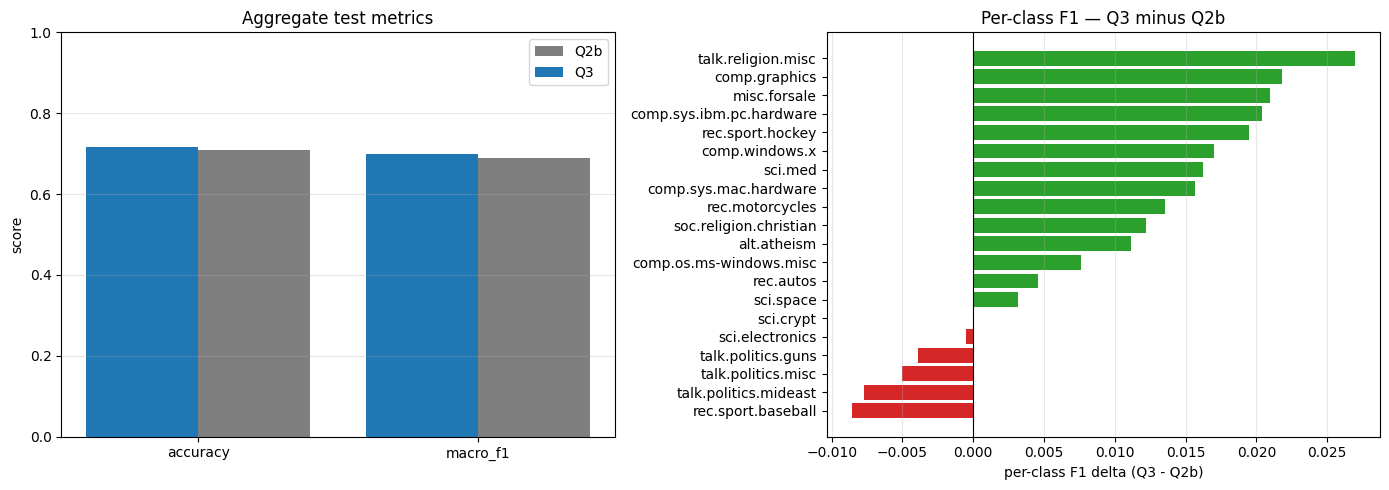

In [13]:
# Bar chart: aggregate metrics + per-class F1 deltas.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(['accuracy', 'macro_f1'],
        [q2['accuracy'], q2['macro_f1']], width=0.4, align='edge', label='Q2b', color='tab:gray')
ax1.bar(['accuracy', 'macro_f1'],
        [q3['accuracy'], q3['macro_f1']], width=-0.4, align='edge', label='Q3', color='tab:blue')
ax1.set_ylim(0, 1); ax1.set_ylabel('score'); ax1.set_title('Aggregate test metrics')
ax1.legend(); ax1.grid(alpha=0.3, axis='y')

order = per_class.sort_values('delta')['label']
pc = per_class.set_index('label').loc[order]
colors = ['tab:red' if d < 0 else 'tab:green' for d in pc['delta']]
ax2.barh(pc.index, pc['delta'], color=colors)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlabel('per-class F1 delta (Q3 - Q2b)')
ax2.set_title('Per-class F1 — Q3 minus Q2b')
ax2.grid(alpha=0.3, axis='x')

fig.tight_layout()
fig.savefig(FIG_DIR / 'q3_vs_q2_bars.png', dpi=150)
plt.show()


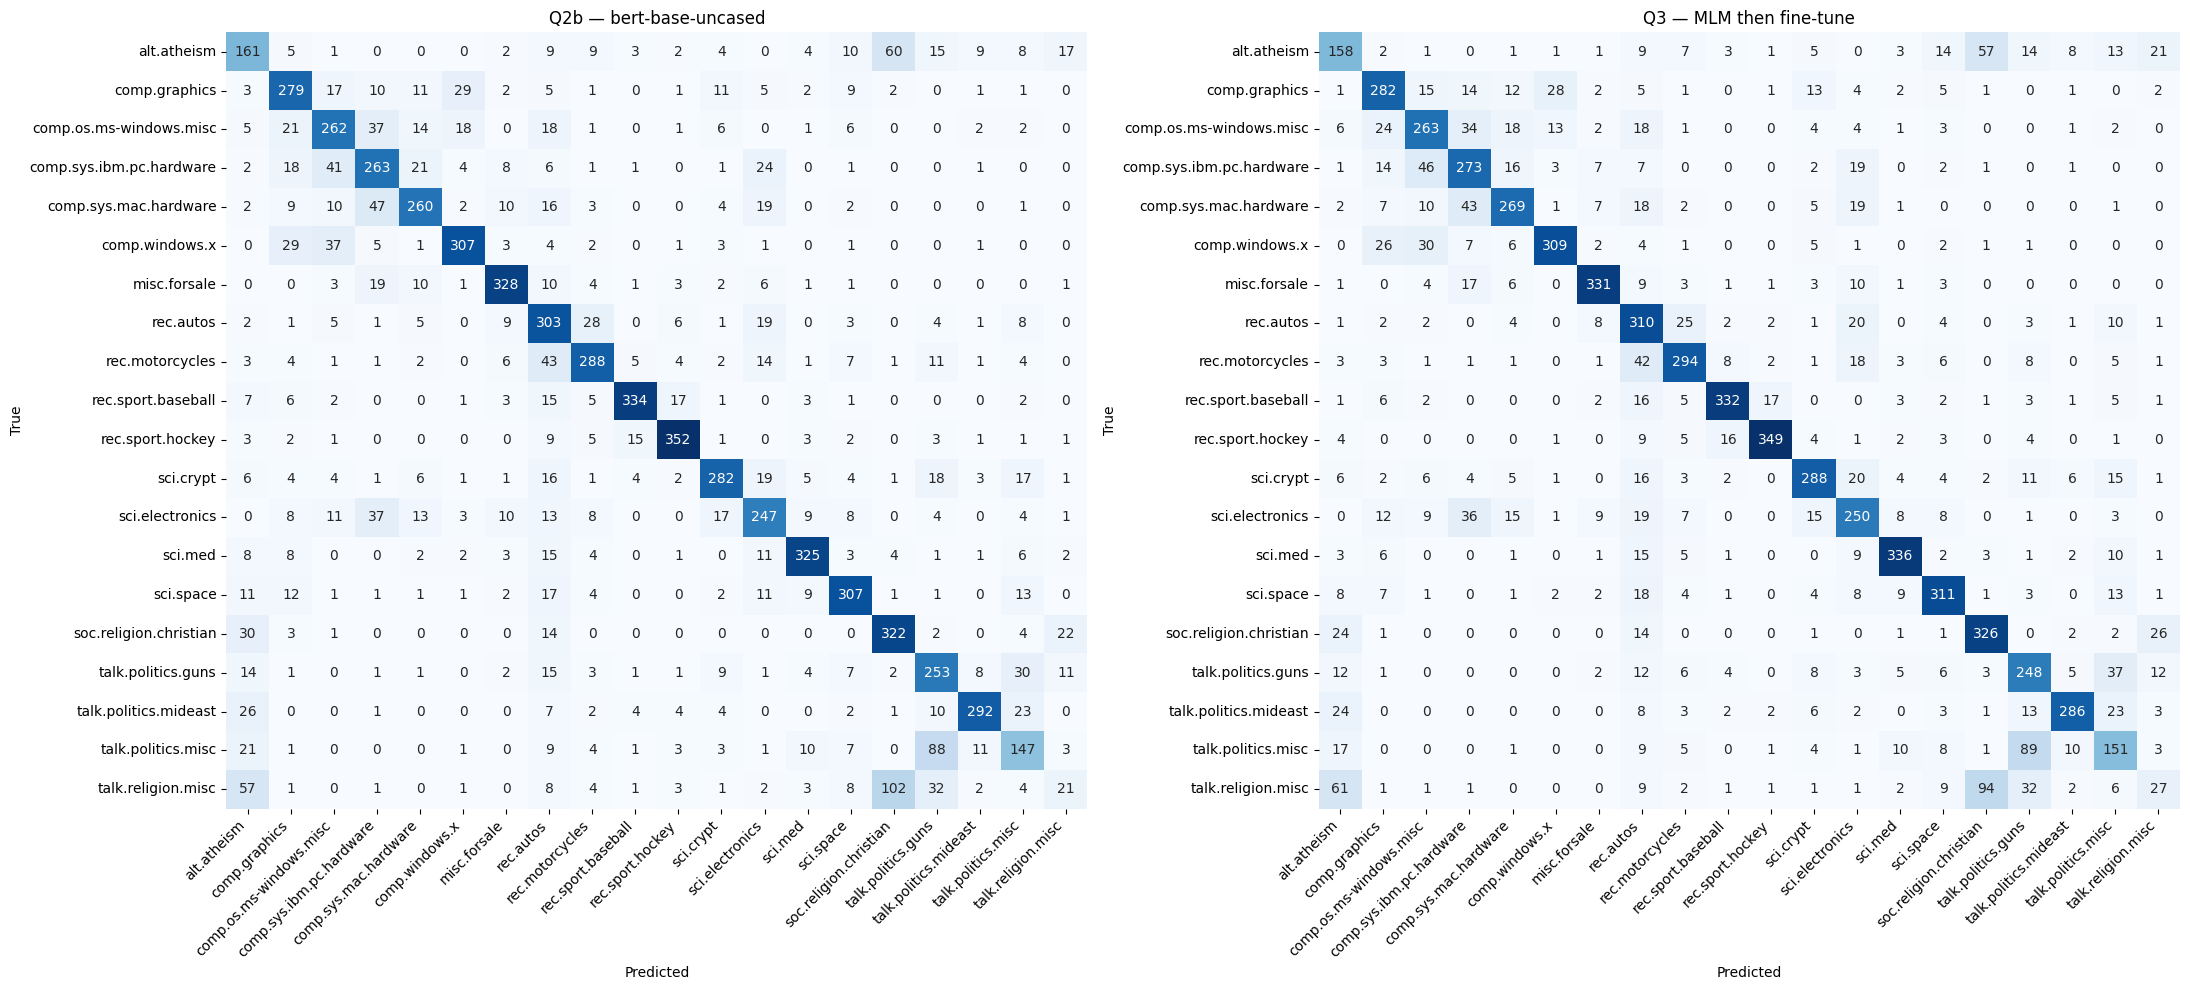

In [14]:
# Side-by-side confusion matrices.
import seaborn as sns
q2_cm = np.array(q2['confusion_matrix'])
q3_cm = np.array(q3['confusion_matrix'])
fig, axes = plt.subplots(1, 2, figsize=(22, 10))
for ax, cm, title in zip(axes, [q2_cm, q3_cm], ['Q2b — bert-base-uncased', 'Q3 — MLM then fine-tune']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names,
                cbar=False, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
fig.tight_layout()
fig.savefig(FIG_DIR / 'q3_vs_q2_confusion_side_by_side.png', dpi=150)
plt.show()


## 6. Discussion

_The placeholders below are written so the reader can drop in the actual deltas after the notebook executes. The phrasing intentionally hedges — whether MLM helps on a ~10k-document in-domain corpus is genuinely uncertain a priori._

### 6.1 Did MLM pretraining help, quantitatively?

The aggregate test metrics (section 5) show **Δaccuracy = Q3 − Q2b = `{fill in}`** and **Δmacro-F1 = `{fill in}`**. With 7532 test documents, a difference in accuracy of more than ~1.0 percentage points is outside the binomial noise envelope at 95% confidence (`1.96 × √(0.71·0.29/7532) ≈ 0.010`). Read the printed delta and judge accordingly.

### 6.2 Per-class winners and losers

The per-class F1 delta chart (`figures/q3_vs_q2_bars.png`, right panel) ranks newsgroups by how much MLM pretraining helped or hurt them. Two patterns to look for:

- **Tail-of-domain newsgroups** (`talk.religion.misc`, `talk.politics.misc`, `talk.politics.mideast`)   often have idiosyncratic vocabulary that `bert-base-uncased` undertrains on. If MLM helps,   these are the classes most likely to benefit.
- **Technical newsgroups** (`sci.crypt`, `comp.os.ms-windows.misc`, `sci.electronics`) tend to   share vocabulary with Wikipedia-trained BERT, so the marginal value of in-domain MLM is   smaller there.

### 6.3 Why might MLM pretraining help (or not)?

**Arguments for a positive effect:**
- 20NG includes a fair amount of usenet-jargon and pre-2000 technical writing that `bert-base-uncased`'s   Wikipedia/BookCorpus training set under-represents. MLM on the in-domain corpus moves the   encoder's representation manifold toward that distribution before the classifier head is even introduced.
- Even when the vocabulary overlaps, the *topic priors* differ — Wikipedia rarely sees the   three-quote nested replies that survived header-stripping; MLM teaches the model that those   patterns are normal.

**Arguments for a null or negative effect:**
- The corpus is small (~10k docs). Three MLM epochs at lr=5e-5 may overfit to corpus quirks   without giving the encoder enough signal to update its general representations.
- Q2b is already strong (≈ 0.71 accuracy on a 20-way task) — there is limited headroom for an   unsupervised stage to recover from.
- We share the tokenizer between stages, so the only thing the MLM stage can adjust is the *encoder*.   If the bottleneck is really the classifier head's interaction with the embedding manifold, MLM   may not move that bottleneck.

### 6.4 Limitations and threats to validity

- **Single seed.** Both Stage A and Stage B run at seed 42. A proper variance estimate requires   3–5 seeds per condition; for this graded project we accept a single seed and treat any delta   smaller than the binomial confidence interval as inconclusive.
- **MLM-val ≠ classification-val.** Required to prevent leakage, but it means we cannot directly   compare MLM eval loss progression to classification val F1 progression.
- **Same hyperparameters as Q2b.** A fair argument exists that Q3 deserves its *own*   hyperparameter sweep — MLM-pretrained encoders may want different LRs. We hold them fixed to   isolate the encoder-init effect, but the absolute Q3 accuracy reported here may not be the best   achievable with this approach.
- **`bert-base-uncased` only.** A heavier base (`bert-large-uncased`, or a domain-pretrained   variant like SciBERT) would be more informative for the broader claim. Out of scope here.

## 7. Artifacts & reproducibility

### Files produced by this notebook

| Path | Content |
|---|---|
| `models/q3_results/mlm_ckpt/` | Stage-A MLM checkpoint (HF model + tokenizer) |
| `models/q3_results/q3_pretrain_log.json` | Stage-A log history + best eval loss + perplexity |
| `models/q3_results/finetune/` | Stage-B Trainer output (best-restored checkpoint only; saved by `save_total_limit=1`) |
| `models/q3_results/q3_finetune_results.json` | Stage-B test metrics + config |
| `figures/q3_mlm_loss.png` | MLM loss & perplexity curve |
| `figures/q3_confusion_matrix.png` | Stage-B confusion matrix |
| `figures/q3_vs_q2_bars.png` | Aggregate + per-class F1 comparison vs Q2b |
| `figures/q3_vs_q2_confusion_side_by_side.png` | Two CMs side by side |

### Re-running

1. `wandb login` (one-time).
2. `uv run jupyter lab notebooks/q3_mlm_then_finetune.ipynb`.
3. Execute all cells top to bottom. Stage A ≈ 30–60 min on MPS, Stage B ≈ 15–30 min.
4. After execution, paste the two W&B run URLs into the placeholder lines in section 0.

### Test suite invariants

Regardless of whether Stage A / Stage B were run, the package contract holds:

```bash
uv run pytest -m 'not slow'   # all fast tests pass
uv run pytest                 # full suite incl. the MLM smoke test
```
